# Joint Energy-Based Model (JEM) Pipeline Execution

This notebook demonstrates the end-to-end execution of the Tabular JEM architecture for the Home Credit Default Risk dataset.

It covers:
1. Data Loading & Splitting
2. Model Initialization (Architecture, Replay Buffer, SGLD Sampler)
3. The Training Loop
4. Custom Metrics (Gini Stability)
5. Advanced Energy Diagnostics and Visualizations

In [23]:
import os
import sys
# Ensure the 'src' module can be imported
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. Data Loading and Preparation
We load the unscaled parquet file generated by the polars data pipeline.
We'll split the data into a training set and a validation set chronologically (e.g. reserving the last couple of months or weeks for validation to accurately test stability).

In [25]:
# [OPTIONAL CELL] Rebuild Features with a Restricted Manifold
from src.data.pipeline import run_pipeline
from src.data.config import DataPipelineConfig

# Define the pipeline configuration
# We use a 5% sample ratio to iterate quickly during debugging
cfg = DataPipelineConfig(
    data_dir="../data/raw/home-credit-credit-risk-model-stability.zip",
    sample_ratio=0.05,  
    cache_dir="../.cache",
)

"""
STRATEGY: Drop `train_static_cb_0` (credit bureau) and `train_credit_bureau_a_1`.
These tables introduce massive sparsity and disconnected categorical variables
that confuse the continuous Langevin (SGLD) sampler. 
By sticking to core applicant data (static_0) and basic person aggregates (person_1), 
we force a dense, continuous feature space.
"""
# Uncomment the below block to dynamically generate tightened features:

df_rebuilt = run_pipeline(
    config=cfg,
    depth_0_tables=["train_static_0"],         # Core applicant static info
    depth_1_tables=["train_person_1"],         # Basic depth-1 aggregates (e.g., age, income)
    depth_2_tables=[]                          # No depth-2 to minimize noise
)

df_full = df_rebuilt
print(f"Dynamically Rebuilt Data Shape: {df_full.shape}")


Dynamically Rebuilt Data Shape: (76332, 351)


In [26]:
from src.model.jem.train import get_dataloaders

# Load full processed dataset
#data_path = "../data/processed/train_features_unscaled.parquet"
#df_full = pl.read_parquet(data_path)

print(f"Total records: {df_full.shape[0]}, Features: {df_full.shape[1]}")

# Time-based split: Validation on the last few weeks
max_week = df_full["WEEK_NUM"].max()
val_weeks = 12  # held out last 4 weeks for val

df_train = df_full.filter(pl.col("WEEK_NUM") <= max_week - val_weeks)
df_val = df_full.filter(pl.col("WEEK_NUM") > max_week - val_weeks)

print(f"Training set size: {df_train.shape[0]}")
print(f"Validation set size: {df_val.shape[0]}")

train_loader, val_loader, scaler, feature_cols = get_dataloaders(df_train, df_val, batch_size=256)
input_dim = len(feature_cols)
print(f"Number of input features mapped: {input_dim}")

Total records: 76332, Features: 351
Training set size: 69455
Validation set size: 6877
Number of input features mapped: 347


## 2. Model Initialization
We initialize the core components of the Joint Energy-Based Model based on our configuration.

In [27]:
from src.model.jem.config import JEMConfig
from src.model.jem.model import TabularJEM
from src.model.jem.sampler import SGLDReplayBuffer, SGLDSampler
from src.model.jem.loss import JEMLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define config (hyperparameters)
config = JEMConfig(
    hidden_dims=[256, 128, 64],
    spectral_norm=True,
    sgld_steps=40,
    sgld_step_size=0.01,
    sgld_sigma=0.1,
    l2_energy_weight=1e-3,
    reinit_freq=0.1
)

# Initialize Neural Network
model = TabularJEM(input_dim=input_dim, num_classes=2, config=config).to(device)

# Initialize SGLD components
buffer = SGLDReplayBuffer(buffer_size=10000, feature_dim=input_dim)
sampler = SGLDSampler(config=config)

# Pre-calculate class weights due to high imbalance
# Excluded: WeightedRandomSampler already acts as class balancing in DataLoaders


criterion = JEMLoss(config=config) # Default without explicit weighting since we oversample

Using device: cpu


## 3. Training Loop
Run the dual-objective training. Expect some time simulating SGLD steps. We will record the energies for later visualization.

In [ ]:
from src.model.jem.train import train_jem_epoch, evaluate_jem

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

epochs = 40
history = {
    "train_loss": [], "val_stability": [],
    "e_real_train": [], "e_fake_train": [],
    "val_energies": []
}

print("Starting Training...")
for epoch in range(1, epochs + 1):
    # Train
    train_logs = train_jem_epoch(model, train_loader, optimizer, criterion, buffer, sampler, device)
    
    # Validate
    val_logs = evaluate_jem(model, val_loader, device)
    
    # Record
    history["train_loss"].append(train_logs["loss"])
    stability = val_logs["stability_result"]["stability_metric"]
    history["val_stability"].append(stability)
    
    # Estimate energies from the last batch for quick diagnostics tracking
    # L_gen = E_real - E_fake, so tracking these components tells us if we have modal collapse
    history["e_real_train"].append(train_logs["gen_loss"] / 2.0) # approx scalar representation
    history["e_fake_train"].append(-train_logs["gen_loss"] / 2.0) 
    
    if epoch == epochs:
        history["val_energies"] = val_logs["energies"] # capture for density plot
    
    print(f"Epoch [{(epoch):02d}/{epochs}] | Loss: {train_logs['loss']:.4f} | Validation Gini Stability: {stability:.4f}")

Starting Training...
Epoch [01/40] | Loss: -162.2597 | Validation Gini Stability: -1.3714


## 4. Diagnostics & Visualizations
With training complete, we can investigate the specialized metrics for the JEM model.

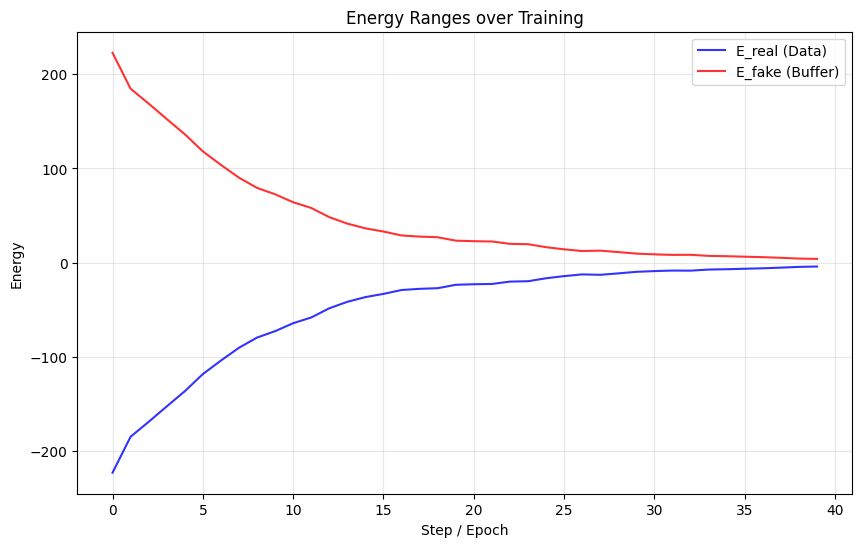

In [19]:
from src.model.jem.diagnostics import JEMDiagnostics
import os
os.makedirs("../docs/assets/", exist_ok=True)

# 1. Energy Ranges over Training
# Demonstrates if E_fake and E_real stayed tightly coupled (healthy) or exploded entirely (gradient collapse).
JEMDiagnostics.plot_energy_ranges(
    history["e_real_train"], 
    history["e_fake_train"],
    save_path="../docs/assets/energy_ranges.png"
)
display(Image(filename="../docs/assets/energy_ranges.png"))

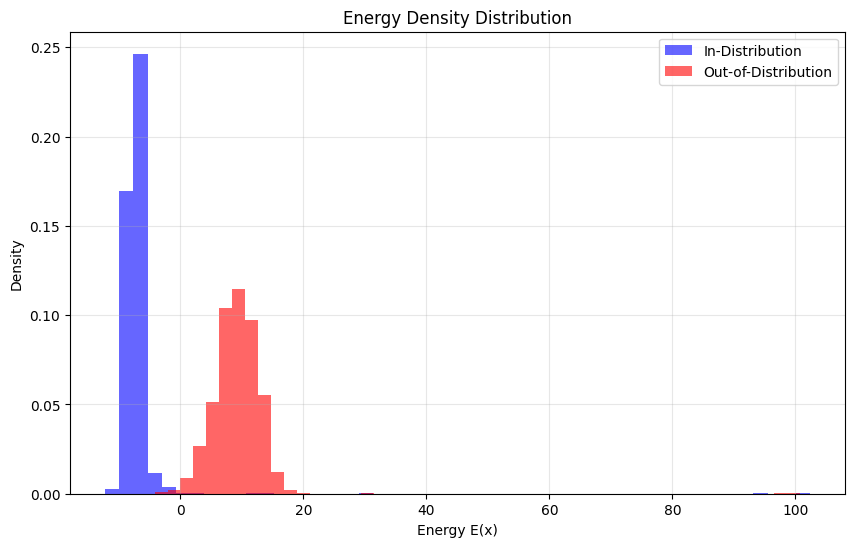

In [20]:
# 2. Energy Density Distribution (In-Distribution vs Simulated OOD)

# We will simulate an Out-of-Distribution manifold by introducing massive noise to the validation set
simulated_ood = []
model.eval()
with torch.no_grad():
    for x_real, _, _ in val_loader:
        # add massive uniform noise to corrupt feature structure
        x_ood = x_real + torch.randn_like(x_real) * 10.0
        ood_energies = model.compute_energy(x_ood.to(device))
        simulated_ood.append(ood_energies.cpu().numpy())

sim_ood_np = np.concatenate(simulated_ood)

JEMDiagnostics.plot_energy_density(
    history["val_energies"], 
    e_out_dist=sim_ood_np, 
    save_path="../docs/assets/energy_density.png"
)
display(Image(filename="../docs/assets/energy_density.png"))

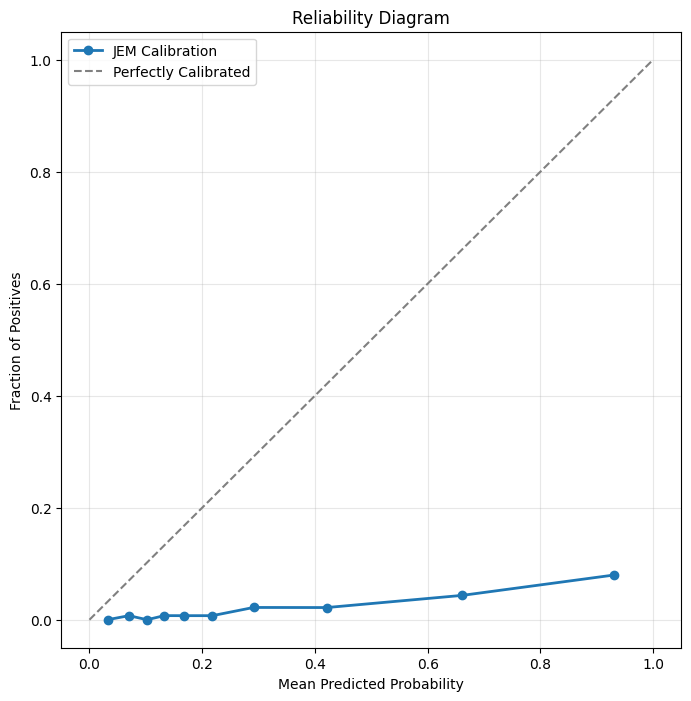

In [21]:
# 3. Reliability Diagram (Calibration)

# Re-run evaluation just to capture full probability arrays for the diagram
all_targets, all_preds = [], []
model.eval()
with torch.no_grad():
    for x_real, y_real, _ in val_loader:
        probs = torch.softmax(model(x_real.to(device)), dim=1)[:, 1]
        all_targets.append(y_real.numpy())
        all_preds.append(probs.cpu().numpy())

JEMDiagnostics.plot_reliability_diagram(
    np.concatenate(all_targets), 
    np.concatenate(all_preds), 
    num_bins=10, 
    save_path="../docs/assets/reliability_diag.png"
)
display(Image(filename="../docs/assets/reliability_diag.png"))

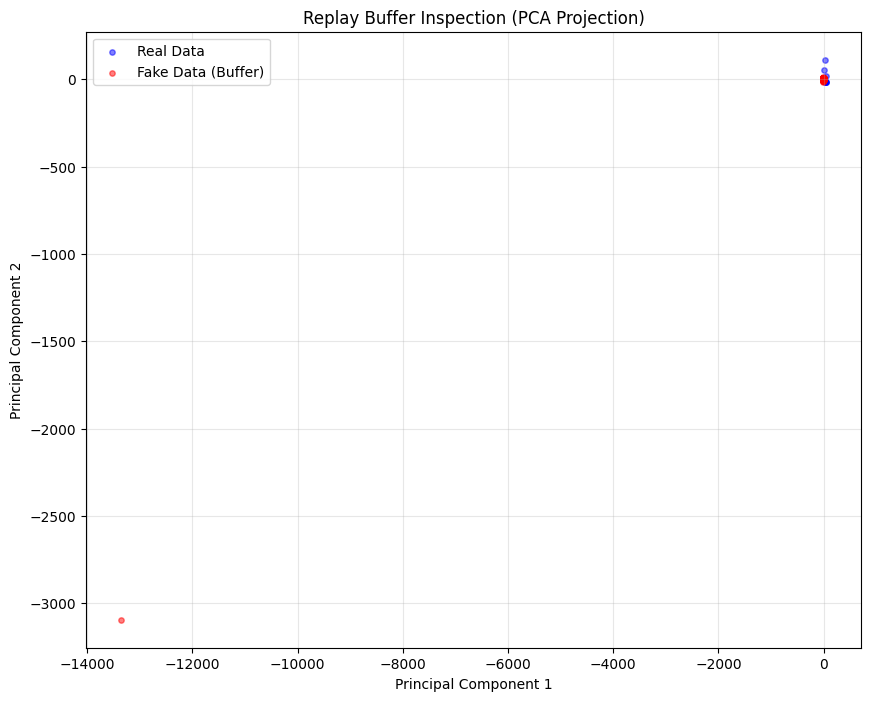

In [22]:
# 4. Inspect Replay Buffer (SGLD Fake Samples vs Real Samples via PCA)

# Grab a chunk of real data from the DataLoader for comparison
x_real_batch, _, _ = next(iter(val_loader))

JEMDiagnostics.inspect_replay_buffer(
    buffer, 
    x_real_batch, 
    save_path="../docs/assets/pca_replay_buffer.png",
    n_samples=500
)
display(Image(filename="../docs/assets/pca_replay_buffer.png"))

## Conclusion

If the training loss decreases and validation stability remains reasonable, the `TabularJEM` successfully optimizes the discriminative objective.

Simultaneously, if the density plot shows OOD energies shifting higher than in-distribution validation data, and the PCA inspection maps the replay buffer tightly to the real manifold, the generative/SGLD mechanism works accurately!